/tmp/ipykernel_3099333/2434003104.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 0.9, 1])  # Adjust the rect to fit the colorbar and xlabel


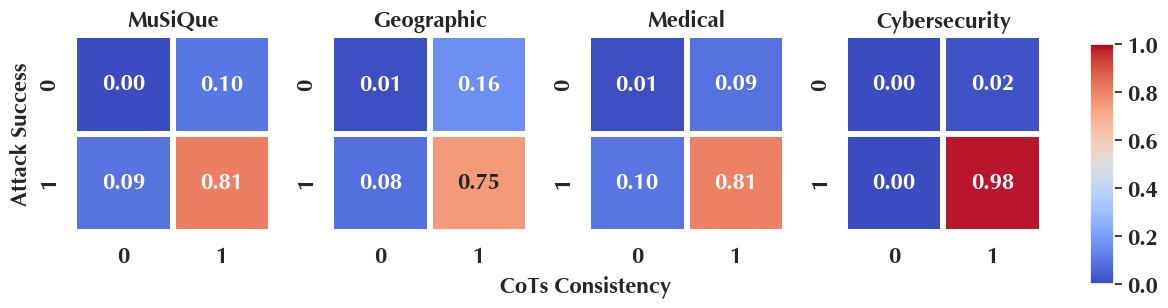

In [15]:
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
import matplotlib

# Set the color palette to 'coolwarm'
sb.set_theme(palette="coolwarm")
plt.rcParams['font.family'] = 'Optima'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.labelsize'] = 16
# Increase the size of the title
plt.rcParams['axes.titlesize'] = 16
# Increase the size of tick labels
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
# matplotlib.rcParams['font.family'] = 'optima'
# matplotlib.rcParams['font.weight'] = 'medium'
# Data initialization and normalization
data = {
    "MuSiQue": [0, 9, 10, 81], #a0c0,a1c0,a0c1,g1s1
    "Geographic": [1, 8, 15, 71], #a0c0,a1c0,a0c1,g1s1
    "Medical": [1, 10, 9, 83],
    "Cybersecurity": [0, 0, 2, 111],
}
for k, v in data.items():
    data[k] = (np.array(v) / np.sum(v)).reshape((2, 2)).T

fig = plt.figure(figsize=(12, 4))  # Adjust figsize to match your example
plt.subplots_adjust(hspace=0.2, wspace=0.2)

# Plot the heatmaps
axes = []  # Store axes for later reference
for i, (name, matrix) in enumerate(data.items()):
    # Determine position of the subplot
    ax = fig.add_subplot(1, 4, i + 1)  # Create subplot
    axes.append(ax)  # Store the axis for later use

    # Plot the heatmap
    sb.heatmap(matrix, annot=True, fmt=".2f", linewidths=3, ax=ax, cbar=False,
               square=True, cmap="coolwarm", vmin=0, vmax=1)
    ax.set_title(name, fontweight='bold')
    # Remove x and y labels
    if i == 0:
        ax.set_ylabel('Attack Success', fontweight='bold')

# Add a shared xlabel between the 2nd and 3rd subplots
fig.text(0.5, 0.13, 'CoTs Consistency', ha='center', fontweight='bold')

# Add a colorbar to the right of the heatmaps
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.6])  # x, y, width, height
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=0, vmax=1))
sm._A = []  # Fake up the array of the scalar mappable to avoid errors
fig.colorbar(sm, cax=cbar_ax)
plt.tight_layout(rect=[0, 0.05, 0.9, 1])  # Adjust the rect to fit the colorbar and xlabel

plt.savefig('cot_heatmap.pdf', bbox_inches='tight')
plt.show()




